In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

In [2]:
data_dir = r"C:\Users\gangliagurdian\Desktop\Mias Folder\new graphs - AC 9152025\data"
all_df = pd.read_csv( os.path.join( data_dir , 'Cluster_detail_results_mp-8-10-12-14-23.csv'))

In [3]:
## BOUT DURATION
# How much time is spent in each cluster
all_df

,ClusterIdx,Timestamp,Folder_Name
0,1,379.3972,1_week8_1
1,1,379.6969,1_week8_1
2,1,379.9966,1_week8_1
3,1,380.2964,1_week8_1
4,1,380.5962,1_week8_1
...,...,...,...
121062,96,42243.7645,7_week23
121063,91,42244.1195,7_week23
121064,96,42244.4695,7_week23
121065,79,42244.8145,7_week23


In [14]:
## Calculate time spent in each cluster - Start Time, End Time, Duration, Cluster, Folder Name
def extract_bouts(df):
    df = df.reset_index(drop=True)
    change = df['ClusterIdx'] != df['ClusterIdx'].shift()
    starts = df.index[change]
    ends = list(starts[1:]) + [len(df)-1]

    bout_data = []
    for start, end in zip(starts, ends):
        duration = df.loc[end, 'Timestamp'] - df.loc[start, 'Timestamp'] + 1
        bout_data.append({
            'start_timestamp': df.loc[start, 'Timestamp'],
            'end_timestamp': df.loc[end, 'Timestamp'],
            'duration': duration,
            'ClusterIdx': df.loc[start, 'ClusterIdx'],
            'Folder_Name': df.loc[start, 'Folder_Name']
        })
    return pd.DataFrame(bout_data)

bout_duration_df = extract_bouts(all_df)
bout_duration_df = bout_duration_df[bout_duration_df['duration'] > 0] #Duration must be positive

In [15]:
def get_week_number(folder_num):
    if folder_num in ["1_week8_1", "2_week8_2"]:
        return 8
    elif folder_num in ["3_week10_1", "4_week10_2"]:
        return 10
    elif folder_num in ["5_week12"]:
        return 12
    elif folder_num in ["6_week14"]:
        return 14
    elif folder_num in ["7_week23"]:
        return 23

bout_duration_df['Week_Number'] = bout_duration_df['Folder_Name'].apply(get_week_number)
bout_duration_df['Week_Number'] = bout_duration_df['Week_Number'].fillna(0).astype(int)
bout_duration_df = bout_duration_df[bout_duration_df['Week_Number'] != 0]

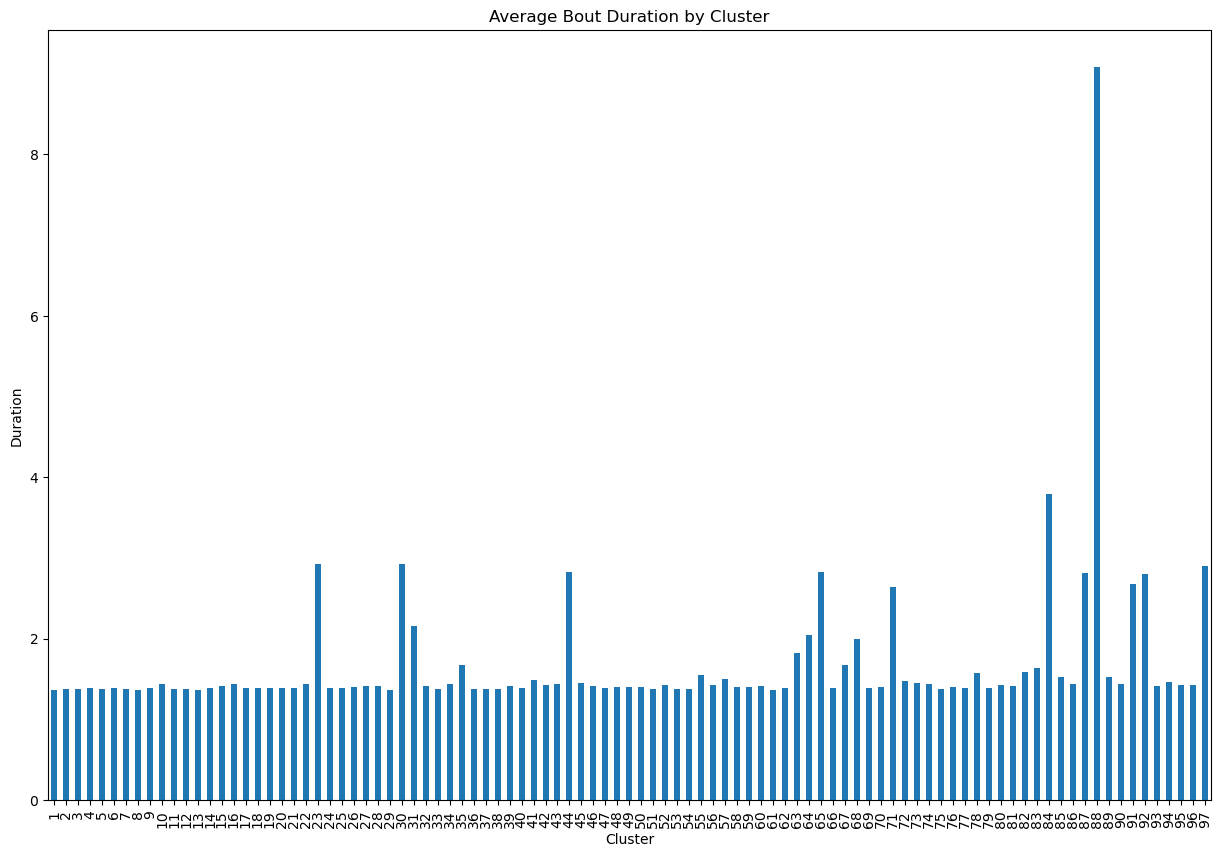

In [43]:
avg_bout_duration_df = bout_duration_df.groupby("ClusterIdx")["duration"].mean()
ax = avg_bout_duration_df.plot(kind="bar", title="Average Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

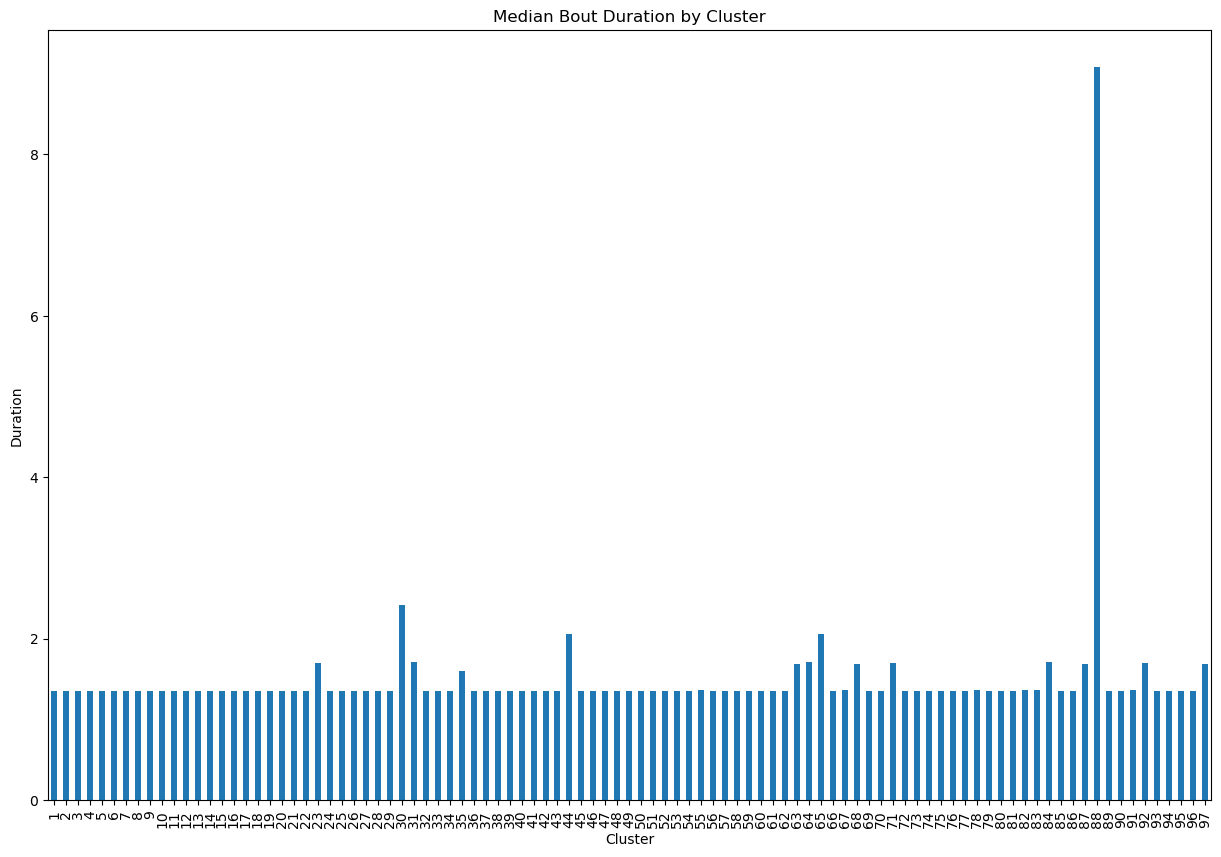

In [23]:
med_bout_duration_df = bout_duration_df.groupby("ClusterIdx")["duration"].median()
ax = med_bout_duration_df.plot(kind="bar", title="Median Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

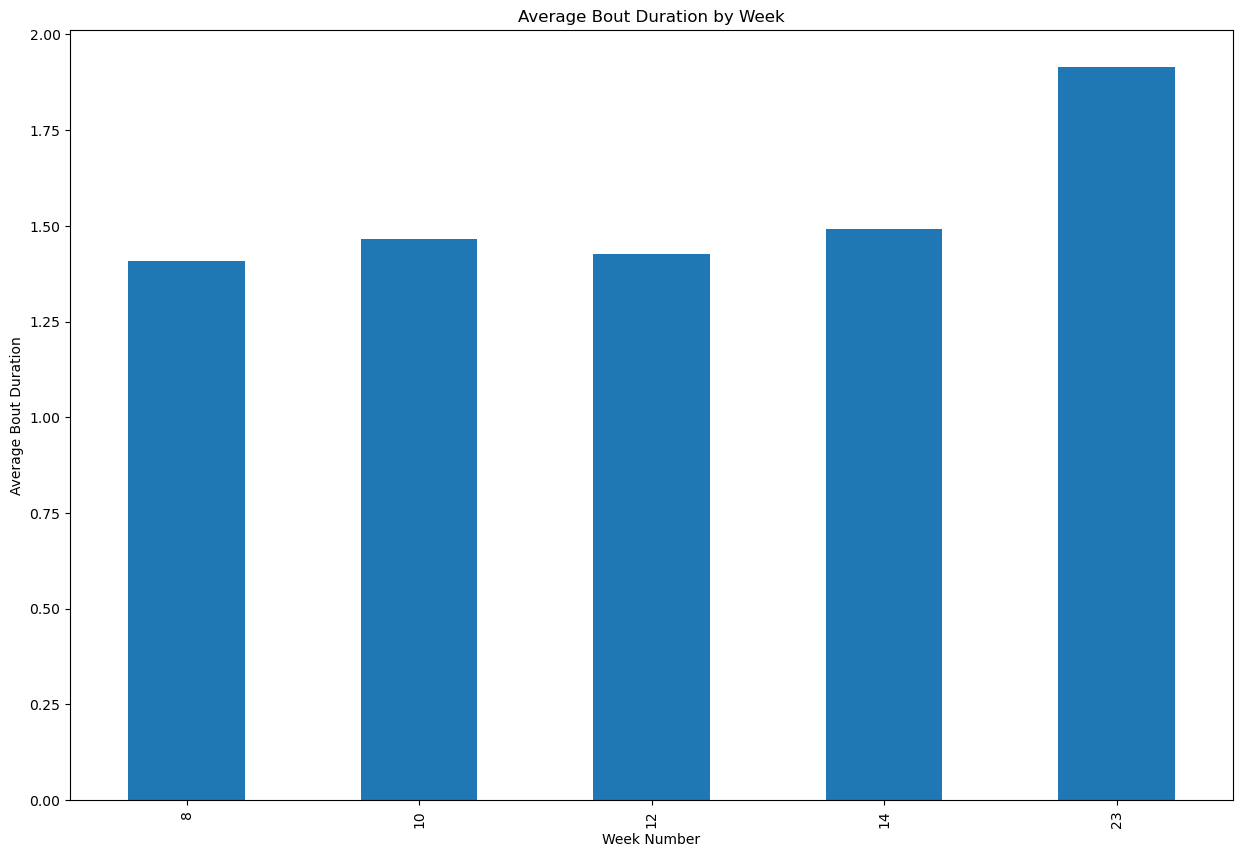

In [104]:
avg_bout_duration_by_week = bout_duration_df.groupby("Week_Number")["duration"].mean()

ax = avg_bout_duration_by_week.plot(
    kind="bar",
    title="Average Bout Duration by Week",
    figsize=(15, 10),
    xlabel="Week Number",
    ylabel="Average Bout Duration"
)

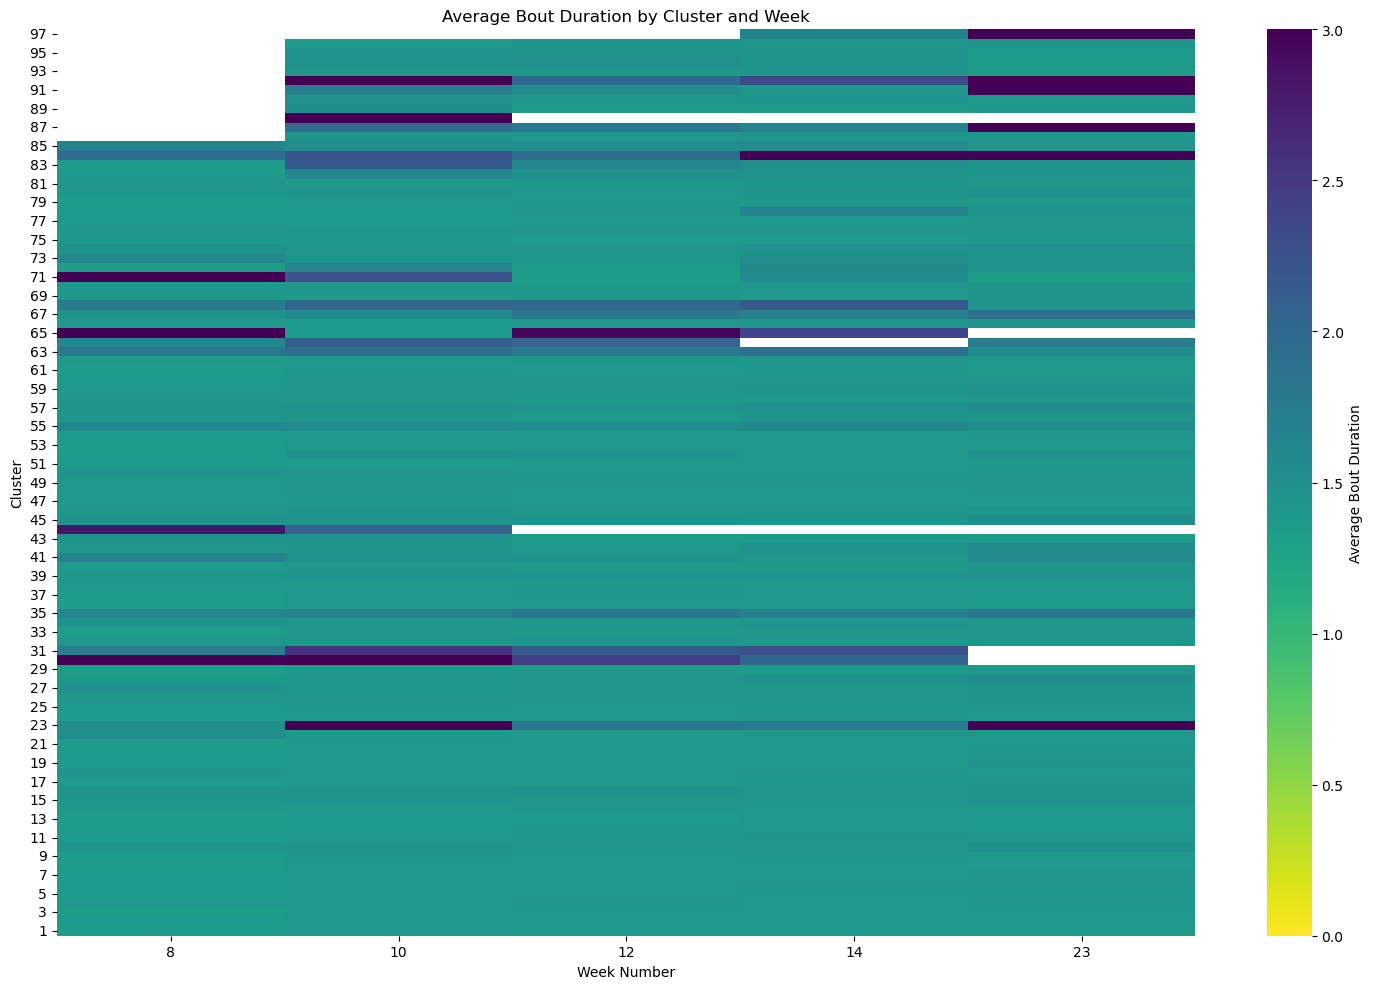

In [20]:
pivot_df = bout_duration_df.groupby(['ClusterIdx', 'Week_Number'])['duration'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=3,
    cbar_kws={'label': 'Average Bout Duration'}
)

ax.invert_yaxis()

plt.title('Average Bout Duration by Cluster and Week')
plt.xlabel('Week Number')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [42]:
# bout_duration_df.to_csv("bout_duration_df_filtered_mp.csv", index=False, header=True, encoding='utf-8')

In [44]:
# # Interval ranges made by evenly separating the counts

# bout_duration_df_filtered['interval'] = pd.qcut(
#     bout_duration_df_filtered["duration"],
#     q=15,
#     duplicates='drop'
# )

# bout_duration_df_filtered['rounded_interval'] = bout_duration_df_filtered['interval'].apply(
#     lambda x: f"{round(x.left)} - {round(x.right)}"
# )

# counts = bout_duration_df_filtered.groupby(['ClusterIdx', 'rounded_interval'], observed=True).size().reset_index(name='count')

# for name, group_df in counts.groupby("ClusterIdx"):
#     ax = group_df.plot(
#         x='rounded_interval',
#         y='count',
#         kind='bar',
#         figsize=(12, 6),
#         legend=False
#     )
#     ax.set_title(f"Bout Duration Counts for Cluster {name}")
#     ax.set_xlabel("Bout Duration Interval")
#     ax.set_ylabel("Count")
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()

In [ ]:
## RECURRENCE INTERVAL
# How much time it takes for clusters to reappear

In [40]:
# Recurrence Time Calculation
recurrence_time_df = bout_duration_df_filtered.sort_values(by=['ClusterIdx', 'start_timestamp']).copy()
recurrence_time_df['recurrence_time'] = recurrence_time_df.groupby('ClusterIdx')['start_timestamp'].diff()

recurrence_time_df_filtered = recurrence_time_df.dropna(subset=['recurrence_time'])

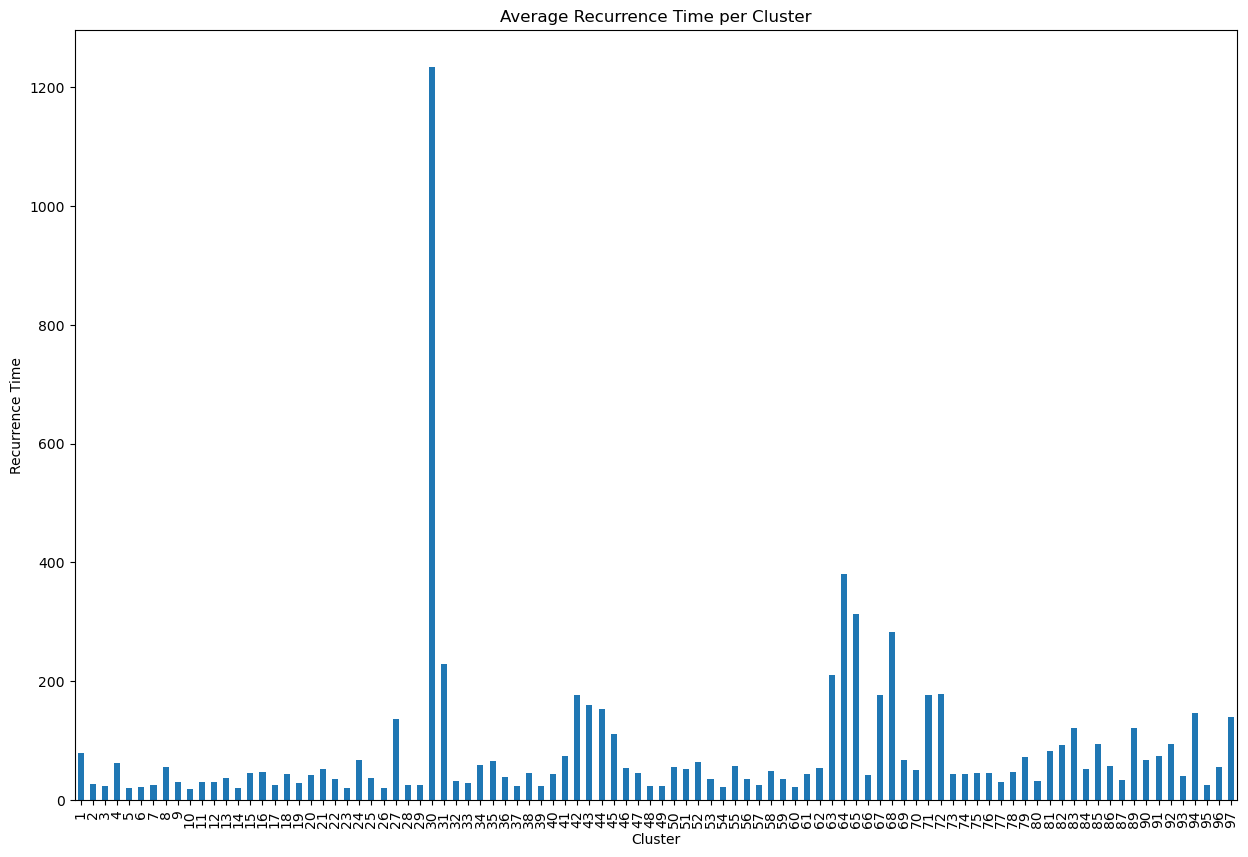

In [41]:
# Mean Recurrence Time Graph
avg_recurrence_time = recurrence_time_df_filtered.groupby("ClusterIdx")["recurrence_time"].mean()
ax = avg_recurrence_time.plot(kind="bar", title="Average Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

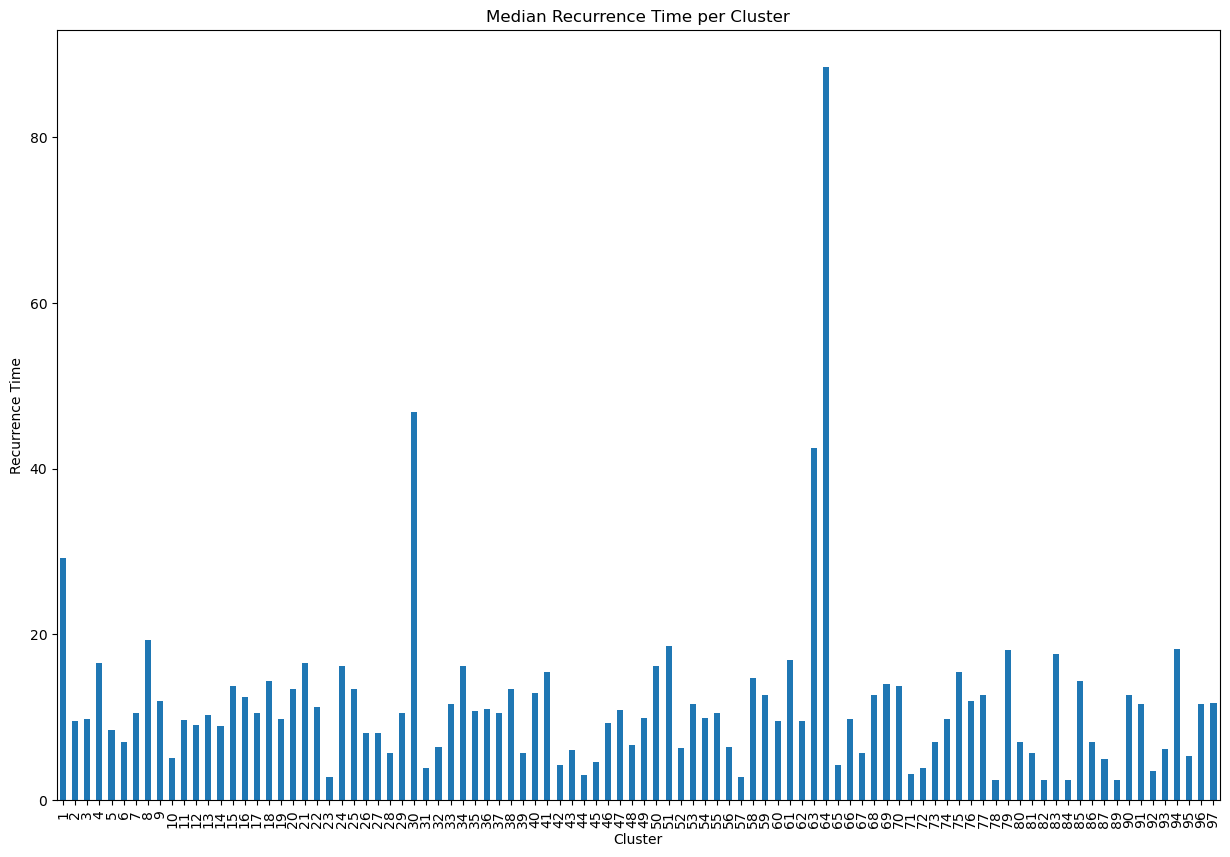

In [39]:
# Median Recurrence Time Graph
med_recurrence_time = recurrence_time_df_filtered.groupby("ClusterIdx")["recurrence_time"].median()
ax = med_recurrence_time.plot(kind="bar", title="Median Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

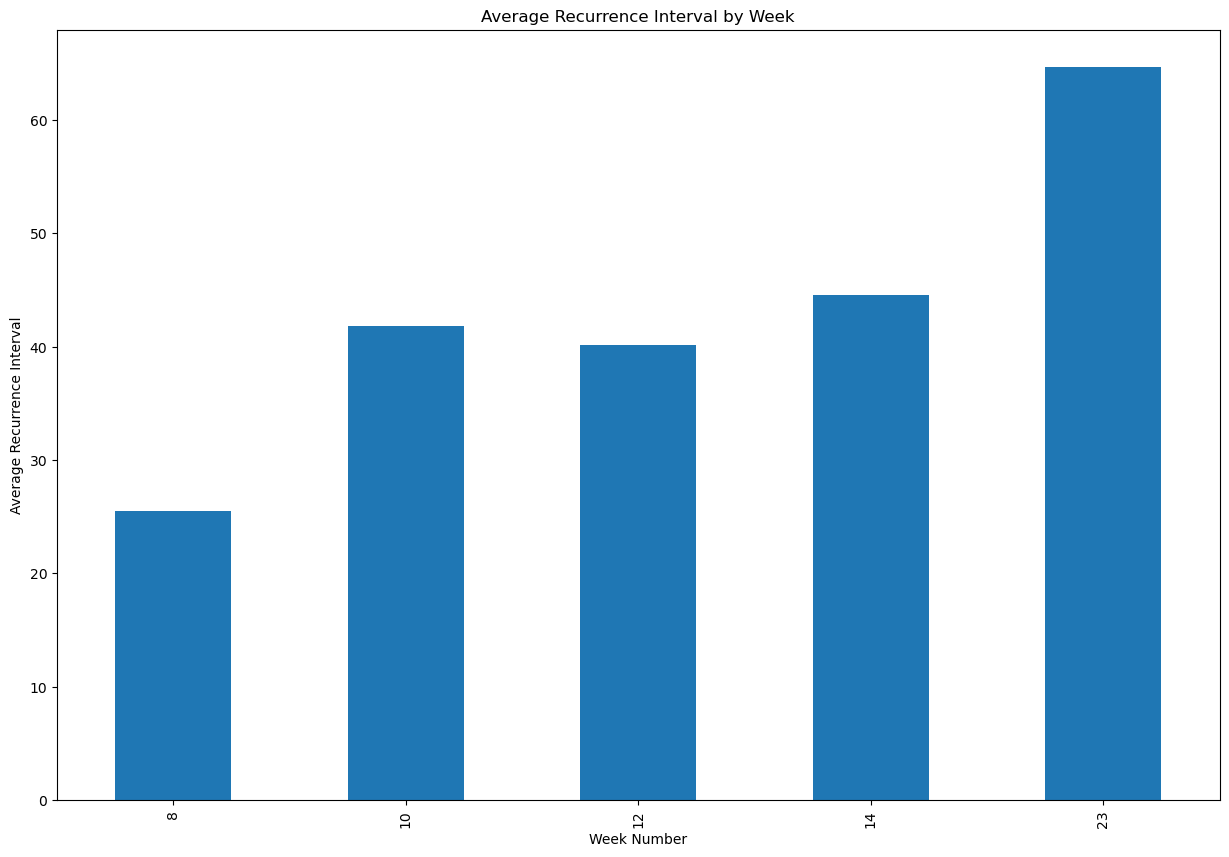

In [28]:
avg_recurrence_duration_by_week = recurrence_time_df_filtered.groupby("Week_Number")["recurrence_time"].mean()

ax = avg_recurrence_duration_by_week.plot(
    kind="bar",
    title="Average Recurrence Interval by Week",
    figsize=(15, 10),
    xlabel="Week Number",
    ylabel="Average Recurrence Interval"
)

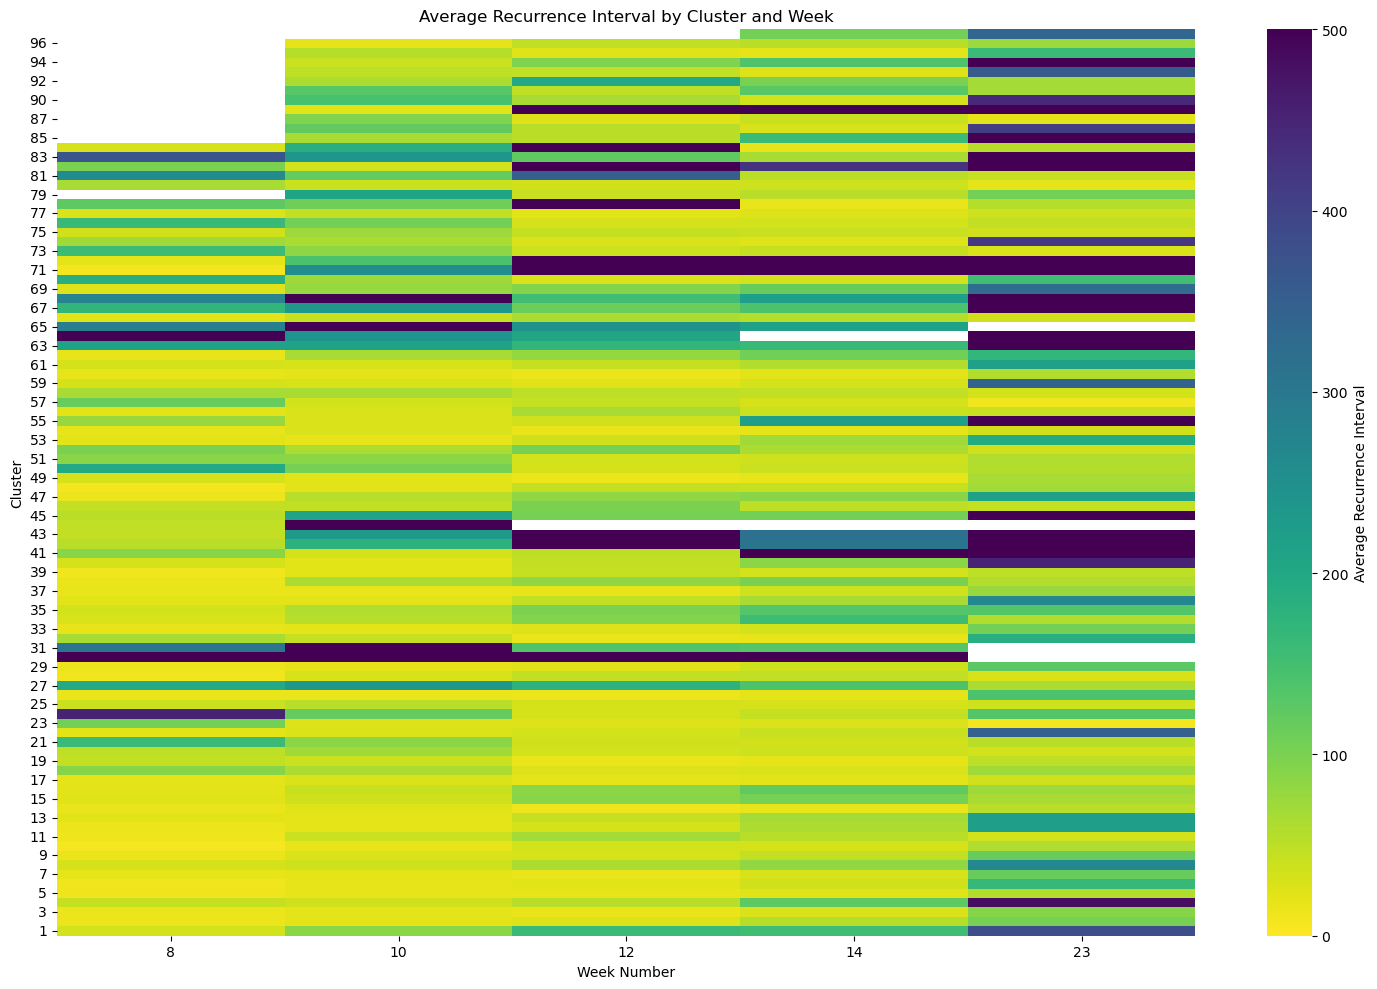

In [29]:
pivot_df = recurrence_time_df_filtered.groupby(['ClusterIdx', 'Week_Number'])['recurrence_time'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=500,
    cbar_kws={'label': 'Average Recurrence Interval'}
)
ax.invert_yaxis()

plt.title('Average Recurrence Interval by Cluster and Week')
plt.xlabel('Week Number')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [23]:
# recurrence_time_df_filtered.to_csv("recurrence_time_df_filtered_mp.csv", index=False, header=True, encoding='utf-8')

In [33]:
# # KDE
# plt.figure(figsize=(20, 8))
# sns.kdeplot(data=recurrence_time_df_filtered, x='recurrence_time', hue='ClusterIdx', common_norm=False, alpha=0.5)
# plt.title("Kernel Density Estimation of Recurrence Times by Cluster")
# plt.xlabel("Recurrence Time")
# plt.ylabel("Density")
# plt.show()

In [42]:
# # Recurrence Intervals by using evenly sorted bins (qcut)
# df = recurrence_time_df_filtered.dropna(subset=['recurrence_time']).copy()
# df = df[df['recurrence_time'] > 0]

# for name, group_df in df.groupby('ClusterIdx'):
#     try:
#         group_df['recurrence_intervals'] = pd.qcut(
#             group_df['recurrence_time'],
#             q=15,
#             duplicates='drop'
#         )
#     except ValueError:
#         group_df['recurrence_intervals'] = pd.qcut(
#             group_df['recurrence_time'],
#             q=3,
#             duplicates='drop'
#         )

#     counts = group_df.groupby('recurrence_intervals').size().reset_index(name='count')

#     ax = counts.plot(
#         x='recurrence_intervals',
#         y='count',
#         kind='bar',
#         legend=False,
#         figsize=(10, 5)
#     )
#     ax.set_title(f"Recurrence Interval Counts - Cluster {name}")
#     ax.set_xlabel("Recurrence Interval")
#     ax.set_ylabel("Count")
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()